In [1]:
import financial_subs as fs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preprocessing

In [12]:
# Get the data
account = pd.read_csv('statements/sep2025.csv')
fs.print_fancy(account)

╒════╤════════════╤═══════════════════════════════════╤═════════════════════════════════════════════╤════════════════════════╤══════════╤══════════╕
│    │ Date       │ Description                       │ Original Description                        │ Category               │   Amount │ Status   │
╞════╪════════════╪═══════════════════════════════════╪═════════════════════════════════════════════╪════════════════════════╪══════════╪══════════╡
│  0 │ 2025-09-30 │ Canva                             │ Canva* 04655-1067069     Kent         DE    │ Electronics & Software │   -94    │ Posted   │
├────┼────────────┼───────────────────────────────────┼─────────────────────────────────────────────┼────────────────────────┼──────────┼──────────┤
│  1 │ 2025-09-30 │ H-E-B                             │ H-E-B  #451              AUSTIN       TX    │ Groceries              │   -27.72 │ Posted   │
├────┼────────────┼───────────────────────────────────┼─────────────────────────────────────────────┼─────

### Renaming and organizing dataframes

In [8]:
# Rename the categories 
account = fs.rename_categories(account)

# Organize known recurring charges
fs.organize_recurring_charges(account)

# Check out the categories left to see if anything is 
unique_account = pd.DataFrame(account.Category.unique(), columns=['Category']).sort_values(by='Category')

print ("\naccount Categories:\n")
fs.print_fancy(unique_account)


account Categories:

╒════╤═══════════════════╕
│    │ Category          │
╞════╪═══════════════════╡
│ 13 │ Bills & Utilities │
├────┼───────────────────┤
│  0 │ Canva             │
├────┼───────────────────┤
│ 17 │ Entertainment     │
├────┼───────────────────┤
│  2 │ Fast Food         │
├────┼───────────────────┤
│ 11 │ Food              │
├────┼───────────────────┤
│  4 │ Gas               │
├────┼───────────────────┤
│  1 │ Groceries         │
├────┼───────────────────┤
│  7 │ Gym               │
├────┼───────────────────┤
│ 12 │ Hair              │
├────┼───────────────────┤
│  5 │ Income            │
├────┼───────────────────┤
│  6 │ Medical           │
├────┼───────────────────┤
│ 19 │ Nails             │
├────┼───────────────────┤
│ 10 │ Pets              │
├────┼───────────────────┤
│ 18 │ Rent              │
├────┼───────────────────┤
│ 14 │ Shipping          │
├────┼───────────────────┤
│  9 │ Shopping          │
├────┼───────────────────┤
│ 20 │ Subscription      │
├────┼

### Inspect any funky categories

In [9]:
# Create a df to hold all transactions for analysis
df = pd.concat([account])
df = df.sort_values(by='Date')

# Print any categories of interest to see what is in there
# fs.print_category(all, 'Gifts & Donations')
# fs.print_category(all, 'Food')
fs.print_category(df, 'Furnishings')

╒════════╤═══════════════╤════════════════════════╤════════════╤══════════╤══════════╕
│ Date   │ Description   │ Original Description   │ Category   │ Amount   │ Status   │
╞════════╪═══════════════╪════════════════════════╪════════════╪══════════╪══════════╡
╘════════╧═══════════════╧════════════════════════╧════════════╧══════════╧══════════╛


### Allocate temporary transactions

In [5]:
# Move anything temporary to a category
df.loc[df['Description'] == 'Zelle Transfer to Reina', 'Category'] = 'Car Payment'
df.loc[df['Description'] == 'Siena Round Rock Web', 'Category'] = 'Rent'
df.loc[df['Description'] == 'Zelle Transfer to Reina', 'Category'] = 'Zelle to Daniela'

### Renaming 'Uncategorized' Category

In [11]:
### See whats in the Uncategorized category - we want to see nothing in here
fs.print_category(df, 'Transfer')

╒════╤════════════╤══════════════════════════════╤═════════════════════════════════════════╤════════════╤══════════╤══════════╕
│    │ Date       │ Description                  │ Original Description                    │ Category   │   Amount │ Status   │
╞════╪════════════╪══════════════════════════════╪═════════════════════════════════════════╪════════════╪══════════╪══════════╡
│ 86 │ 2025-09-03 │ USAA Funds Transfer DB       │ USAA FUNDS TRANSFER DB                  │ Transfer   │   -61    │ Posted   │
├────┼────────────┼──────────────────────────────┼─────────────────────────────────────────┼────────────┼──────────┼──────────┤
│ 82 │ 2025-09-04 │ USAA Funds Transfer DB       │ USAA FUNDS TRANSFER DB                  │ Transfer   │    -5    │ Posted   │
├────┼────────────┼──────────────────────────────┼─────────────────────────────────────────┼────────────┼──────────┼──────────┤
│ 83 │ 2025-09-04 │ USAA Funds Transfer DB       │ USAA FUNDS TRANSFER DB                  │ Transfer   

In [6]:
# Recheck categories
unique_account = pd.DataFrame(df.Category.unique(), columns=['Category']).sort_values(by='Category')
print ("\naccount Categories:\n")
fs.print_fancy(unique_account)


account Categories:

╒════╤═══════════════════╕
│    │ Category          │
╞════╪═══════════════════╡
│  6 │ Bills & Utilities │
├────┼───────────────────┤
│ 20 │ Canva             │
├────┼───────────────────┤
│  9 │ Entertainment     │
├────┼───────────────────┤
│ 12 │ Fast Food         │
├────┼───────────────────┤
│ 17 │ Food              │
├────┼───────────────────┤
│  3 │ Gas               │
├────┼───────────────────┤
│ 15 │ Groceries         │
├────┼───────────────────┤
│ 18 │ Gym               │
├────┼───────────────────┤
│ 16 │ Hair              │
├────┼───────────────────┤
│ 10 │ Income            │
├────┼───────────────────┤
│ 19 │ Medical           │
├────┼───────────────────┤
│ 11 │ Nails             │
├────┼───────────────────┤
│  7 │ Pets              │
├────┼───────────────────┤
│  1 │ Rent              │
├────┼───────────────────┤
│ 14 │ Shipping          │
├────┼───────────────────┤
│  2 │ Shopping          │
├────┼───────────────────┤
│  0 │ Subscription      │
├────┼

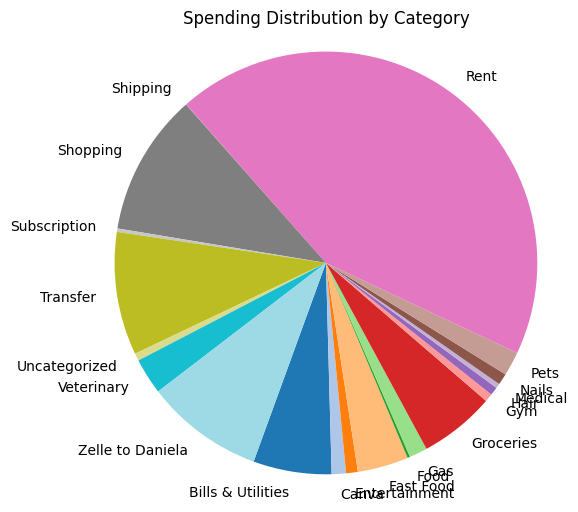

In [7]:
# spending_by_category = fs.get_visualization_df(df, 1)
filtered_df = df[(df['Amount'] < 0)]
filtered_df.loc[:, 'Amount'] = filtered_df['Amount'].abs()
spending_by_category = filtered_df.groupby('Category')['Amount'].sum()
fs.show_pie_chart(spending_by_category)

# Analysis

### account Summary



account Pay: $7163.88
account Expense: $-8617.63
account Net: $-1453.75





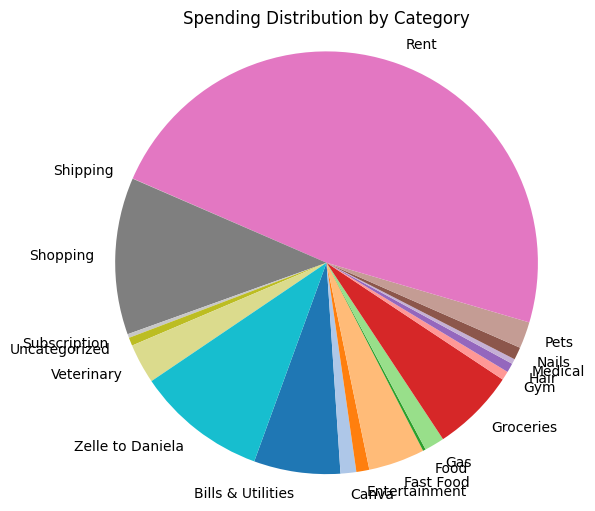

In [10]:
account_income = fs.get_income(account)
account_expense = fs.get_expenses(account)

# print_fancy(account)
fs.print_stats(account_income, account_expense, "account")
      
spending_by_category = fs.get_visualization_df(df, 1)
fs.show_pie_chart(spending_by_category)

In [55]:
fs.print_category(account, 'Shopping')

╒═════╤════════════╤════════════════════════╤══════════════════════════════════════════╤════════════╤══════════╤══════════╕
│     │ Date       │ Description            │ Original Description                     │ Category   │   Amount │ Status   │
╞═════╪════════════╪════════════════════════╪══════════════════════════════════════════╪════════════╪══════════╪══════════╡
│   0 │ 2025-10-31 │ Spirit Halloween       │ SPIRIT HALLOWEEN 60069   609-703-8292 TX │ Shopping   │   -49.75 │ Posted   │
├─────┼────────────┼────────────────────────┼──────────────────────────────────────────┼────────────┼──────────┼──────────┤
│  11 │ 2025-10-27 │ Spencer's              │ SPENCER GIFTS 440        868-284-0048 TX │ Shopping   │   -85.49 │ Posted   │
├─────┼────────────┼────────────────────────┼──────────────────────────────────────────┼────────────┼──────────┼──────────┤
│  14 │ 2025-10-27 │ Go Calendars Games Boo │ GO  CALENDARS GAMES BOO  AUSTIN       TX │ Shopping   │   -32.45 │ Posted   │
├─────┼─

# Visualizations

### Spending by Category

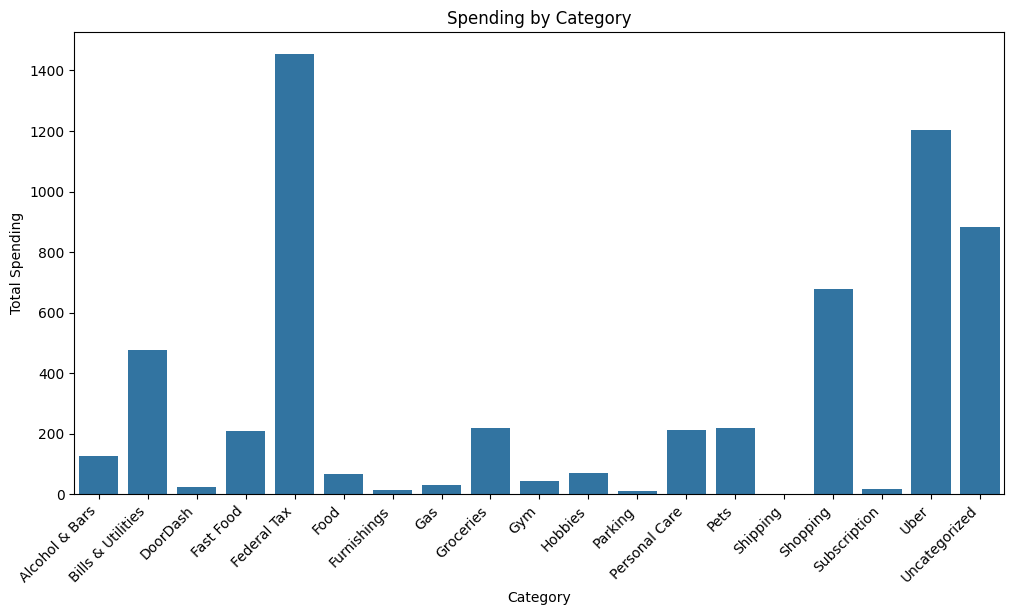

In [57]:
filtered_df = all[(all['Amount'] < 0) & (all['Category'] != 'Transfer')]
filtered_df.loc[:, 'Amount'] = filtered_df['Amount'].abs()
spending_by_category = filtered_df.groupby('Category')['Amount'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=spending_by_category.index, y=spending_by_category.values)
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Category')
plt.ylabel('Total Spending')
plt.title('Spending by Category')
plt.show()

In [ ]:
plt.figure(figsize=(12 ,12))
plt.pie(spending_by_category, labels=spending_by_category.index, startangle=250)
plt.axis('equal')
plt.title('Spending Distribution by Category')
plt.show()